# Problem Set 5, Part 1

## Exercise 1: Policy Gradient

1. Define the MDP underlying the above environment.
2. Draw out the backup diagram for this environment.
3. **(*)Can you define an optimal deterministic policy for this environment? If so,
write it out. If not, why not?**\n

 - The optimal outcome is the baked_sugary_cookies state (+10)
    - *empty_bowl* -> prepare_dough()
    - *full_bowl* -> add_sugar()
    - *sugared_bowl* -> cook()
    - __*baked_sugary_cookies*__ -> restart()
    
4. **(*) Can you define an optimal stochastic policy for this environment? If so, write
it out. If not, why not?**

The optimal stochastic policy for this environment is the same as the deterministic policy as the probabilities for the actions is always 1 

5. Define the MDP underlying the above environment.
6. Draw out the backup diagram for this environment.
7. **(*) Can you define an optimal deterministic policy for this environment? If so,
write it out. If not, why not?**

 - The optimal outcome is still the baked_sugary_cookies state (+10)
    - *empty_bowl* -> prepare_dough()
    - *full_bowl* -> add_ingredient()
    - *enriched_bowl* -> taste()
      - if *sugared_bowl* -> cook()
        - __*baked_sugary_cookies*__ -> restart()
      - else -> restart()
    

8. **(*) Can you define an optimal stochastic policy for this environment? If so, write
it out. If not, why not?**

With the introduced inability to discriminate between salt and sugar, there has been added a necessary step to taste before cooking. But since there is no extra cost in the tasting step, the optimal stochastic policy is still the same as the deterministic. Had there been a cost to the tasting step then there would maybe be different percentages 

9. **(*) How does this setup differ from the previous one?**

The removal of the ability to see what is added to the dough introduced the state *enriched_bowl* with a hidden variable σ. In the previous environment the *taste* action had no use as you were already certain of the contents of the bowl, but now that action is instrumental to avoid baking salty cookies

10.  Is there any modification to the MDP that you would naturally suggest and which
would improve your ability in defining a deterministic or stochastic policy?


## Exercise 2: Continuous Actions
1. Recall how we defined the neural networks so that the output would give a dis-
tribution over the actions.
2. Suggest a possible distribution function to model your policy.
3. Consider what sort of parameters or statistics you would need to work with the
distribution you have chosen.
4. **(*) How would you define your neural network to have a distribution over R in
output?**

To define a neural network whose output is a distribution over $\mathbb{R}$, I would let the network output the parameters of a continuous probability distribution rather than probabilities for a finite set of actions.

A natural choice is a gaussian policy. In that case, given a state $s$ the neural network outputs:

- a mean $\mu(s)$,
- a standard deviation $\sigma(s)$.

The policy is then defined as
$$
\pi(a \mid s) = \mathcal{N}(a; \mu(s), \sigma^2(s)).
$$

So the architecture would be:

- input: the state $s$,
- hidden layers: standard fully connected layers,
- output layer: two neurons,
  - one for $\mu(s)$,
  - one for $\sigma(s)$.

The network therefore does not output a single action directly. Instead, it outputs the parameters of a Gaussian distribution over all real valued actions and the action is sampled as
$$
a \sim \mathcal{N}(\mu(s), \sigma^2(s)).
$$

In this way the neural network defines a valid probability distribution over the continuous action space $\mathbb{R}$. This is the continuous analogue of using a softmax layer in the discrete action case, instead of outputting probabilities for finitely many actions, it outputs the parameters of a continuous density.

5. What assumptions underlie your choice for the probability distribution?

## Exercise 3: MAB and Baselines
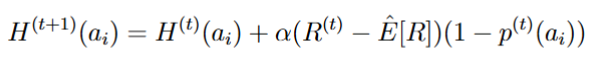

1. **(*) Which term in this expression plays a role analogous to a baseline in a policy
gradient algorithms?**

Expected reward (E[R]) plays the role of the "baseline". The algorithm compares the actual return R^(t) to this "baseline". 

2. **(*) How does this term affect the learning process in the gradient bandit algo-
rithm?**

The action is updated to be more preferred if the actual reward is better than the expected reward. If the actual reward is less than the expected reward, the actions preference is decreased




## Exercise 4: Actor-critic methods 
1. In which sense actor and critic may be assimilated to these two processes of
reinforcement learning?